In [4]:
with open("./names.txt", "r") as f:
    names = f.read().splitlines()

print(f"Tototal number of names in dataset is: {len(names)}")
lengths = [n for n in names]
sorted_lengths = sorted(lengths, key=len)
print(f"Shortest name is {sorted_lengths[0]} with length {len(sorted_lengths[0])}")
print(f"Longest name is {sorted_lengths[-1]} with length {len(sorted_lengths[-1])}")

Tototal number of names in dataset is: 32033
Shortest name is an with length 2
Longest name is muhammadmustafa with length 15


## Bigrams

In [7]:
bi = dict()

# <S> special start character
# <E> special end character
for n in names:
    chs = ["<S>"] + list(n) + ["<E>"]
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        bi[bigram] = bi.get(bigram, 0) + 1

In [ ]:
sorted(bi.items(), key=lambda kv: -kv[1])  # or reverse = True

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [ ]:
import torch
import numpy as np

N = np.zeros((27, 27), dtype=np.int32)

chars = sorted(list(set("".join(names))))

ctoi = {c: i + 1 for i, c in enumerate(chars)}
ctoi["."] = 0
itoc = {i: c for c, i in ctoi.items()}
# ctoi['<E>'] = 27

for n in names:
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1, idx2 = ctoi[ch1], ctoi[ch2]
        N[idx1, idx2] += 1

KeyError: '<S>'

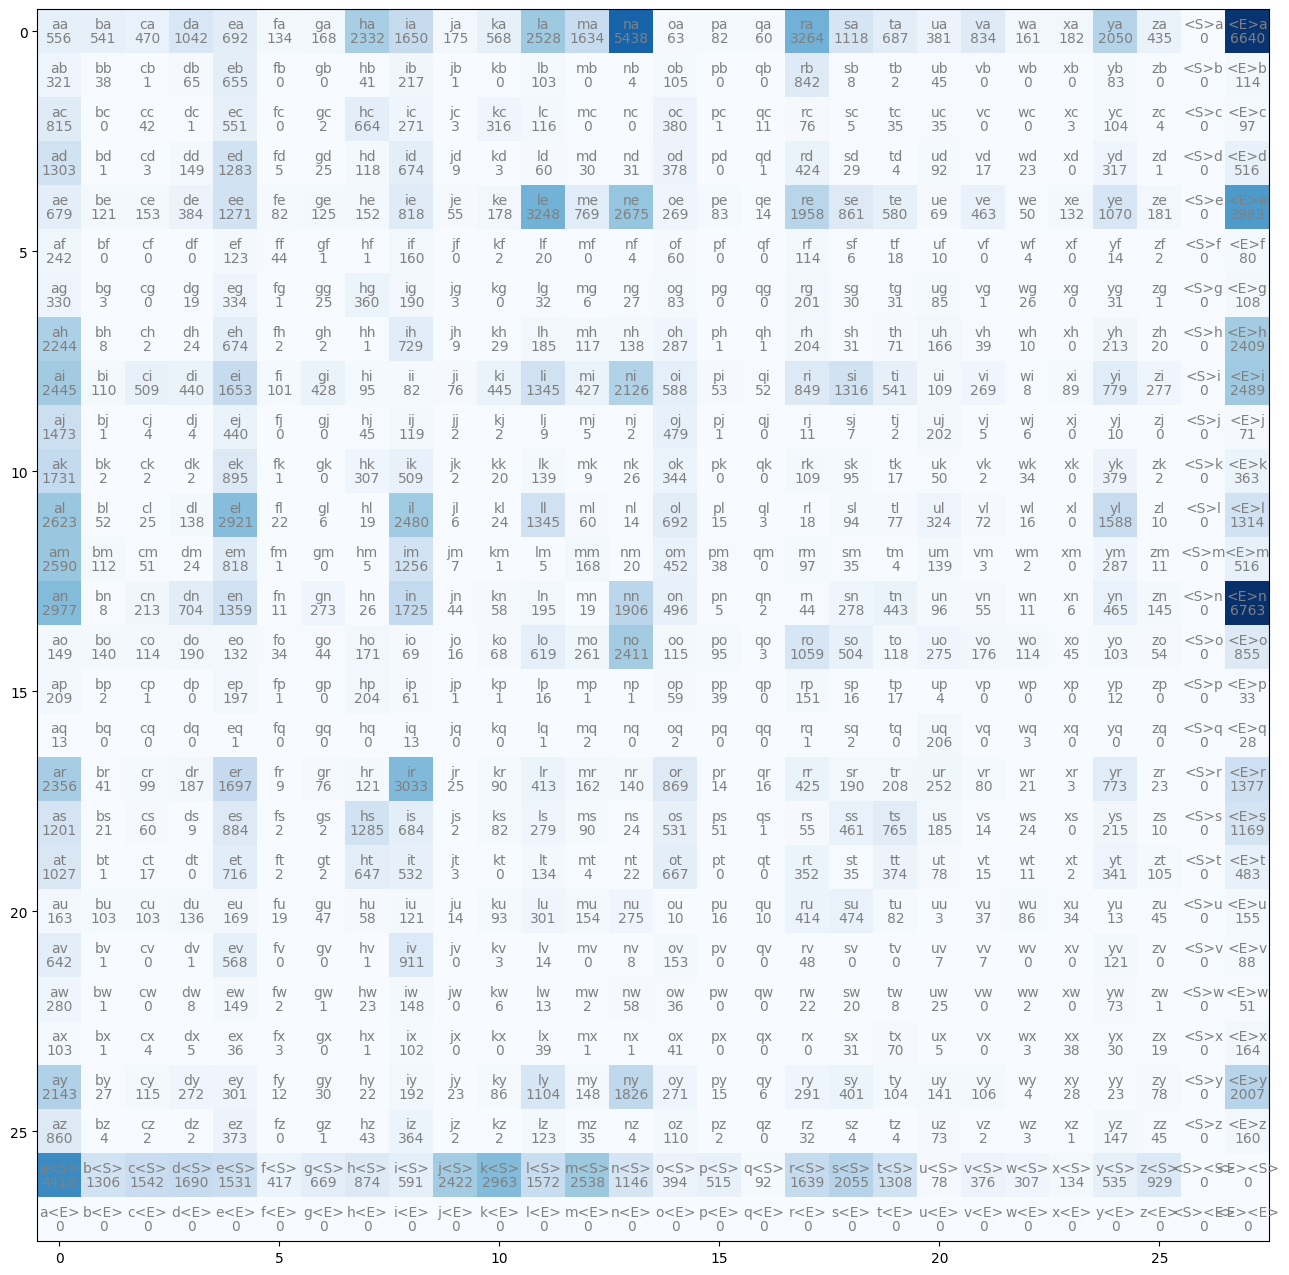

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(16, 16))
plt.imshow(N, cmap="Blues")
for i in range(28):
    for j in range(28):
        chtrs = itoc[i] + itoc[j]
        plt.text(i, j, chtrs, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j], ha="center", va="top", color="gray")